# M5 Raw Data Exploration

Dataset Description

In the challenge, you are predicting item sales at stores in various locations for two 28-day time periods. Information about the data is found in the M5 Participants Guide.
Files

    calendar.csv - Contains information about the dates on which the products are sold.
    sales_train_validation.csv - Contains the historical daily unit sales data per product and store [d_1 - d_1913]
    sample_submission.csv - The correct format for submissions. Reference the Evaluation tab for more info.
    sell_prices.csv - Contains information about the price of the products sold per store and date.
    sales_train_evaluation.csv - Includes sales [d_1 - d_1941] (labels used for the Public leaderboard)

## 1. Libraries


In [45]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "m5" / "raw"

calendar_path = RAW_DATA_DIR / "calendar.csv"
sales_path = RAW_DATA_DIR / "sales_train_validation.csv"
prices_path = RAW_DATA_DIR / "sell_prices.csv"

RAW_DATA_DIR

WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/data/m5/raw')

## 2. File Overview

Checks size of the raw files

In [ ]:
raw_files = []

for file_path in sorted(RAW_DATA_DIR.glob("*.csv")):
    raw_files.append({
        "file_name": file_path.name,
        "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
    })

files_df = pd.DataFrame(raw_files)
files_df

,file_name,size_mb
0,calendar.csv,0.10
1,sales_train_evaluation.csv,116.10
2,sales_train_validation.csv,114.45
3,sample_submission.csv,4.99
4,sell_prices.csv,193.97


## 3. Load Raw Data

Calendar, sales and price files

In [106]:
calendar = pd.read_csv(calendar_path)
sales = pd.read_csv(sales_path) #, nrows=1000)
prices = pd.read_csv(prices_path) #, nrows=100000)

print("calendar shape:", calendar.shape)
print("sales sample shape:", sales.shape)
print("prices sample shape:", prices.shape)

calendar shape: (1969, 14)
sales sample shape: (30490, 1919)
prices sample shape: (6841121, 4)


## 4. Calendar Data exploration

The calendar table links M5 day numbers like **d_1** to real dates and event information.

In [49]:
calendar.shape

(1969, 14)

In [50]:
calendar.columns

Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='str')

In [52]:
calendar.head(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [7]:
calendar.tail()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [53]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [54]:
calendar.dtypes

date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d                 str
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

In [55]:
calendar.isna().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [57]:
calendar.describe(include="all")

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [58]:
calendar.nunique()

date            1969
wm_yr_wk         282
weekday            7
wday               7
month             12
year               6
d               1969
event_name_1      30
event_type_1       4
event_name_2       4
event_type_2       2
snap_CA            2
snap_TX            2
snap_WI            2
dtype: int64

In [59]:
calendar["weekday"].unique()

<StringArray>
['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 7, dtype: str

In [60]:
calendar["event_type_1"].value_counts(dropna=False)

event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

In [63]:
calendar.shape[0]/7

281.2857142857143

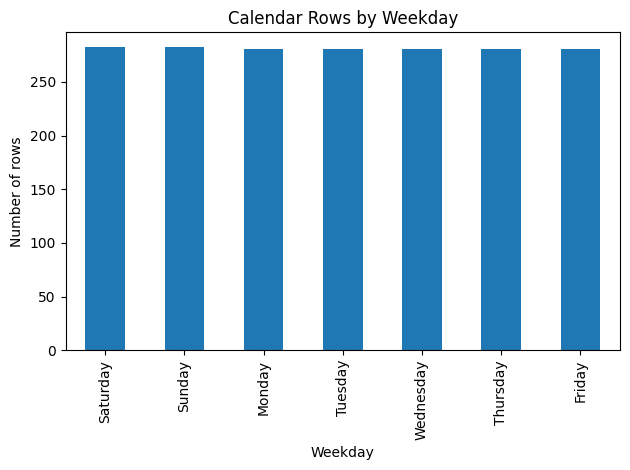

In [ ]:
calendar["weekday"].value_counts().plot(kind="bar", title="Weekday counts")
plt.xlabel("Weekday")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

The calendar data has one row per M5 day. It includes normal date fields, event columns, and SNAP indicator columns for different states.

## 5. Sales Data exploration

The sales table is wide 
Product and store details are in the first columns, then daily sales are stored in columns d_1, d_2, ..., d_n

Each row is a unique item_id-store_id

In [86]:
sales.shape

(30490, 1919)

In [66]:
sales.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='str', length=1919)

In [87]:
sales.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,...,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,0,1,4,0,0,0,1,0,1,0,0,0,2,0,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,1,0,1,0,0,1,1
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,0,4,6,5,7,...,4,5,2,8,4,0,0,1,37,3,4,6,3,2,1
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,0,2,3,9,0,...,1,0,7,0,0,0,0,1,1,6,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0,0,0,2,0,2


In [88]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [89]:
sales.dtypes.head(15)

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
state_id      str
d_1         int64
d_2         int64
d_3         int64
d_4         int64
d_5         int64
d_6         int64
d_7         int64
d_8         int64
d_9         int64
dtype: object

In [90]:
sales.isna().sum().head(15)

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
d_4         0
d_5         0
d_6         0
d_7         0
d_8         0
d_9         0
dtype: int64

In [ ]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,...,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,0.756674,0.775927,0.779141,0.867334,1.142440,...,1.766350,1.391505,1.281371,1.154247,1.230863,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,3.665969,3.697822,3.486595,3.484608,4.636395,...,4.290072,3.620804,3.329683,2.933918,3.303282,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,279.000000,258.000000,163.000000,107.000000,133.000000,...,124.000000,122.000000,123.000000,89.000000,142.000000,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [92]:
sales.nunique().head(15)

id          30490
item_id      3049
dept_id         7
cat_id          3
store_id       10
state_id        3
d_1            84
d_2            82
d_3            72
d_4            79
d_5            63
d_6            84
d_7            85
d_8           100
d_9            91
dtype: int64

In [93]:
sales["cat_id"].unique()

<StringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str

In [94]:
sales["store_id"].unique()

<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

In [95]:
sales["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [96]:
sales["store_id"].value_counts()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

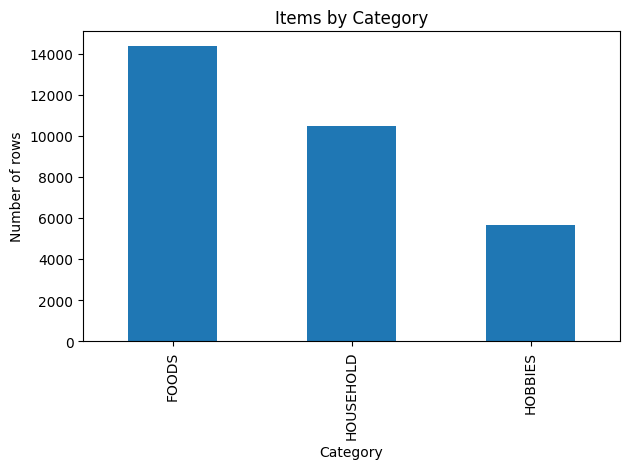

In [97]:
sales["cat_id"].value_counts().plot(kind="bar", title="Items by Category")
plt.xlabel("Category")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

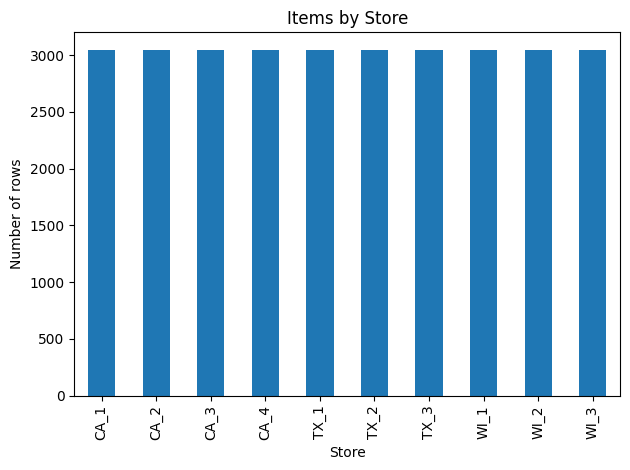

In [100]:
sales["store_id"].value_counts().plot(kind="bar", title="Items by Store")
plt.xlabel("Store")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

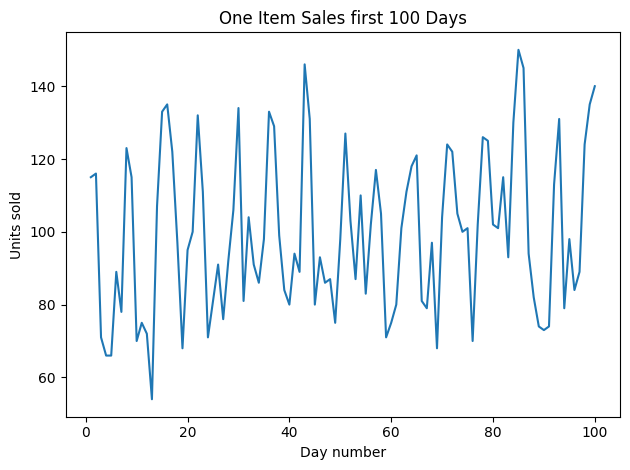

In [103]:
day_columns = [column for column in sales.columns if column.startswith("d_")]
first_n_days = day_columns[:100]

# Find an item with sales in the first 100 days
sales["first_100_total"] = sales[first_n_days].sum(axis=1)
item_index = sales["first_100_total"].idxmax()

one_item_sales = sales.loc[item_index, first_n_days]
one_item_sales.index = range(1, len(one_item_sales) + 1)

one_item_sales.plot(kind="line", title="One Item Sales first 100 Days")
plt.xlabel("Day number")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

Sales must be transformed from wide to large format

## 6. Sell Prices Data Sample

The prices table track the selling price for each item, store, and Walmart week.

In [107]:
prices.shape

(6841121, 4)

In [108]:
prices.columns

Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='str')

In [110]:
prices.head(10)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


In [111]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [112]:
prices.dtypes

store_id          str
item_id           str
wm_yr_wk        int64
sell_price    float64
dtype: object

In [113]:
prices.isna().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [115]:
prices.nunique()

store_id        10
item_id       3049
wm_yr_wk       282
sell_price    1048
dtype: int64

In [116]:
prices["store_id"].unique()

<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

In [117]:
prices["store_id"].value_counts()

store_id
TX_2    701214
TX_1    699796
CA_1    698412
WI_3    696094
CA_3    693990
TX_3    691112
CA_4    679025
WI_2    678171
WI_1    665912
CA_2    637395
Name: count, dtype: int64

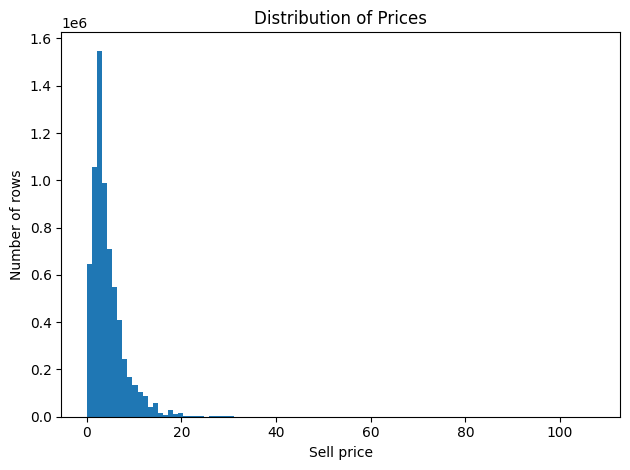

In [126]:
prices["sell_price"].plot(kind="hist", bins=100, title="Distribution of Prices")
plt.xlabel("Sell price")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

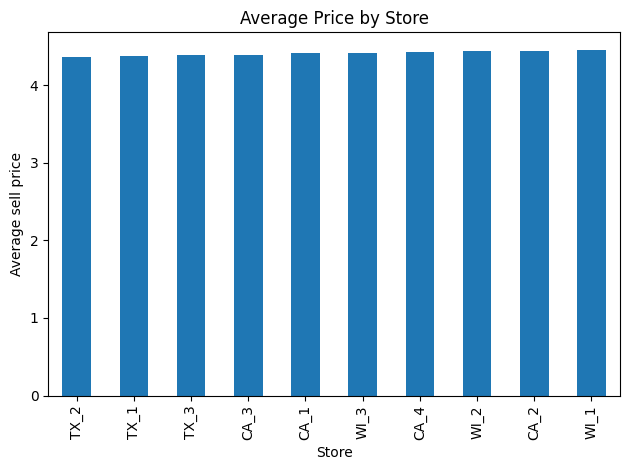

In [128]:
prices.groupby("store_id")["sell_price"].mean().sort_values().plot(kind="bar", title="Average Price by Store")
plt.xlabel("Store")
plt.ylabel("Average sell price")
plt.tight_layout()
plt.show()

The sell price data is useful because prices can change over time. This table can be joined to sales data using `store_id`, `item_id`, and `wm_yr_wk`.

### Price over time example

In [130]:
# Pick one item and store with fluctuating prices
price_changes = (
    prices
    .sort_values(["store_id", "item_id", "wm_yr_wk"])
    .groupby(["store_id", "item_id"])["sell_price"]
    .nunique()
    .sort_values(ascending=False)
)

price_changes.head()

store_id  item_id    
TX_3      FOODS_1_095    21
TX_1      FOODS_1_095    21
WI_1      FOODS_1_129    20
CA_2      FOODS_1_095    18
WI_3      FOODS_1_129    18
Name: sell_price, dtype: int64

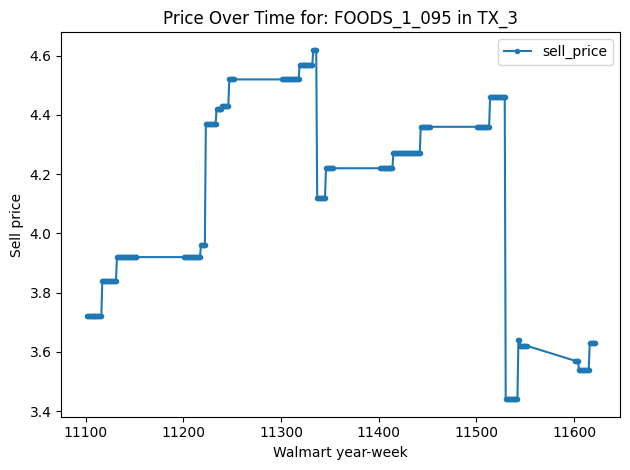

In [132]:
one_store, one_item = price_changes.index[0]

price_history = prices[
    (prices["item_id"] == one_item) &
    (prices["store_id"] == one_store)
].copy()

price_history = price_history.sort_values("wm_yr_wk")

price_history.plot(
    x="wm_yr_wk",
    y="sell_price",
    kind="line",
    marker="o",
    markersize=3,
    title=f"Price Over Time for: {one_item} in {one_store}"
)

plt.xlabel("Walmart year-week")
plt.ylabel("Sell price")
plt.tight_layout()
plt.show()


## Summary

- calendar.csv has dates properties and events for each `d_` day code.
- sales_train_validation.csv contains item/store identifiers and daily sales in wide format.
- sell_prices.csv has weekly prices by item and store.

Actions
- The sales table is wide, need to be melt to large format.
- The files can be joined using day/week, item, and store columns.